In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# plot consistency across all charts
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})


In [6]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 44,988 rows × 14 columns


## Feature Overview

Before diving into distributions, we catalogue the unique values in categorical columns. This helps us understand the cardinality of each feature, spot any unexpected categories, and decide on encoding strategies later (label encoding vs. one-hot).


### Unique Values in Categorical Columns

Low-cardinality categoricals (e.g., gender, home ownership) are natural candidates for one-hot encoding. High-cardinality ones may need target encoding or grouping.


In [7]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']

for col in cat_cols:
    vals = df[col].unique()
    print(f"  {col}  ({len(vals)} categories):  {list(vals)}")


  person_gender  (2 categories):  ['female', 'male']
  person_education  (5 categories):  ['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
  person_home_ownership  (4 categories):  ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
  loan_intent  (6 categories):  ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
  previous_loan_defaults_on_file  (2 categories):  ['No', 'Yes']


### Cardinality of All Columns

High cardinality in a numeric column (many distinct values) is expected. In a categorical column, high cardinality might require special treatment.


In [8]:
cardinality = pd.DataFrame({
    'Unique Values': {col: df[col].nunique() for col in df.columns},
    'Dtype': df.dtypes
})
cardinality.sort_values('Unique Values', ascending=False)


,Unique Values,Dtype
loan_percent_income,43668,float64
person_income,33981,float64
loan_amnt,4481,float64
loan_int_rate,1302,float64
credit_score,334,int64
person_age,51,float64
person_emp_exp,51,int64
cb_person_cred_hist_length,29,float64
loan_intent,6,object
person_education,5,object


## Univariate Analysis

Now, we examine each feature independently. The goal is to understand each variable's distribution, detect skew, and flag any remaining data quality concerns.

### Applicant Age

**Why it matters:** Most lending policies have minimum (and sometimes maximum) age requirements. The distribution post-cleaning should be roughly bell-shaped, peaking in the 25–45 range typical for loan applicants.


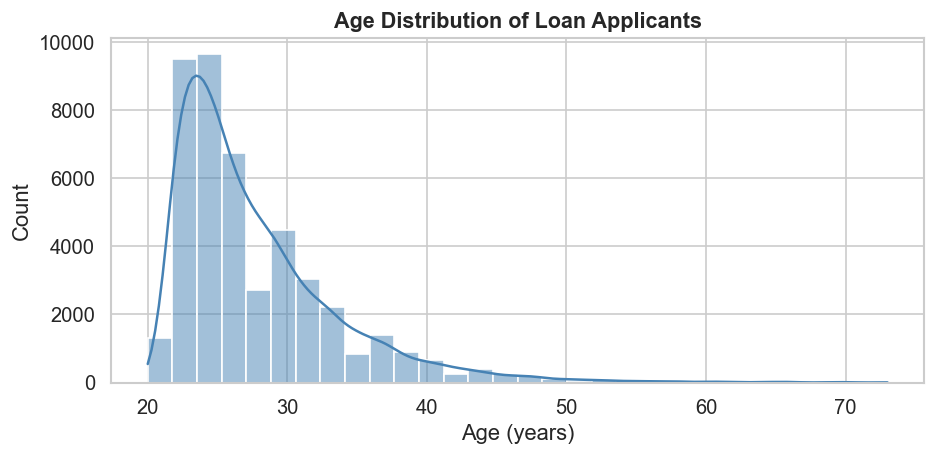

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['person_age'], bins=30, kde=True, ax=ax, color='steelblue')
ax.set_title("Age Distribution of Loan Applicants", fontsize=13, fontweight='bold')
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Gender Distribution

**Why it matters:** Gender parity analysis is critical in fintech for fair lending compliance (e.g., Equal Credit Opportunity Act). A heavily skewed gender split in the dataset may introduce bias into any model trained on it.


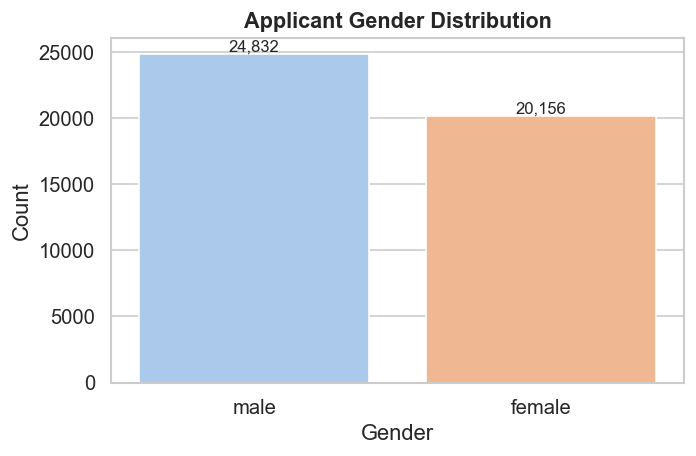

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df['person_gender'].value_counts().index
sns.countplot(data=df, x='person_gender', order=order, ax=ax, palette='pastel')
ax.set_title("Applicant Gender Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


### Education Level

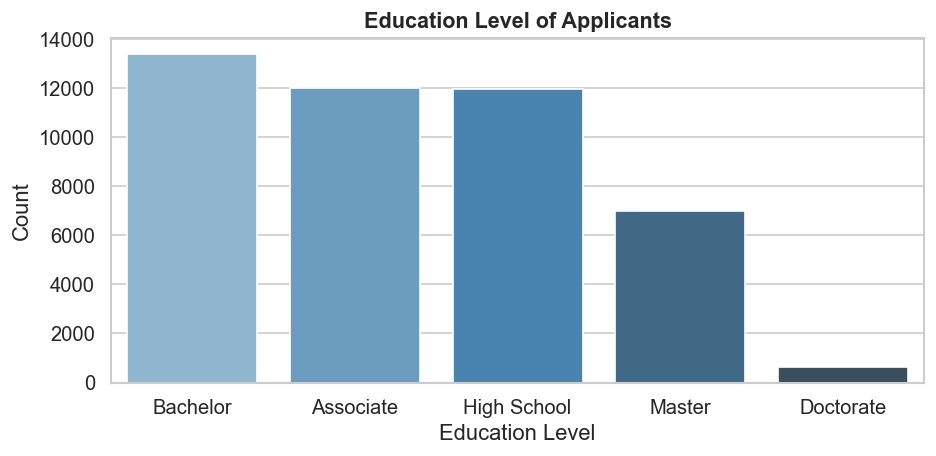

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
order = df['person_education'].value_counts().index
sns.countplot(data=df, x='person_education', order=order, ax=ax, palette='Blues_d')
ax.set_title("Education Level of Applicants", fontsize=13, fontweight='bold')
ax.set_xlabel("Education Level")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Annual Income

**Why it matters:** Income is the single most important determinant of repayment capacity. We expect a right-skewed distribution (most people earn moderate amounts, very few earn extremely high amounts). We use a log scale on the x-axis to make this skew interpretable.

> **Fintech insight:** Lenders typically use income to compute the **Debt-to-Income (DTI)** ratio — a core underwriting metric.


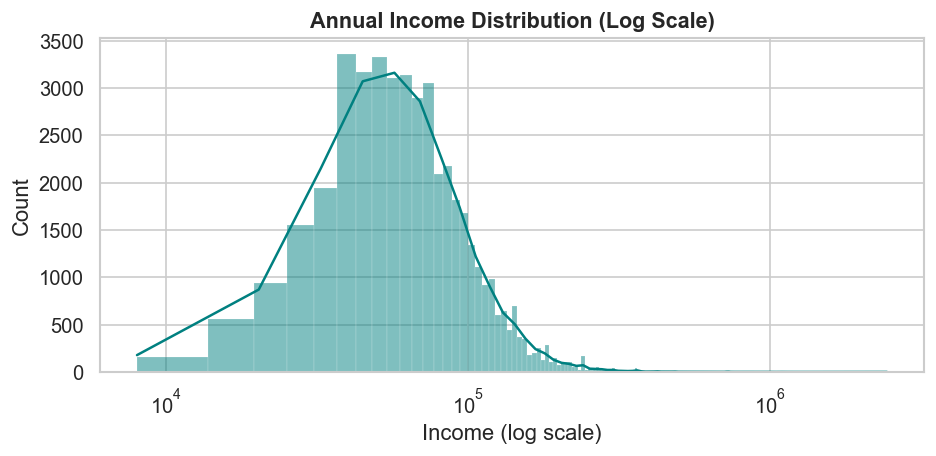

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['person_income'], kde=True, ax=ax, color='teal')
ax.set_xscale('log')
ax.set_title("Annual Income Distribution (Log Scale)", fontsize=13, fontweight='bold')
ax.set_xlabel("Income (log scale)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Employment Experience

**Why it matters:** More the years of employment, more it signals towards stability. Applicants with more continuous employment history are generally considered lower risk.

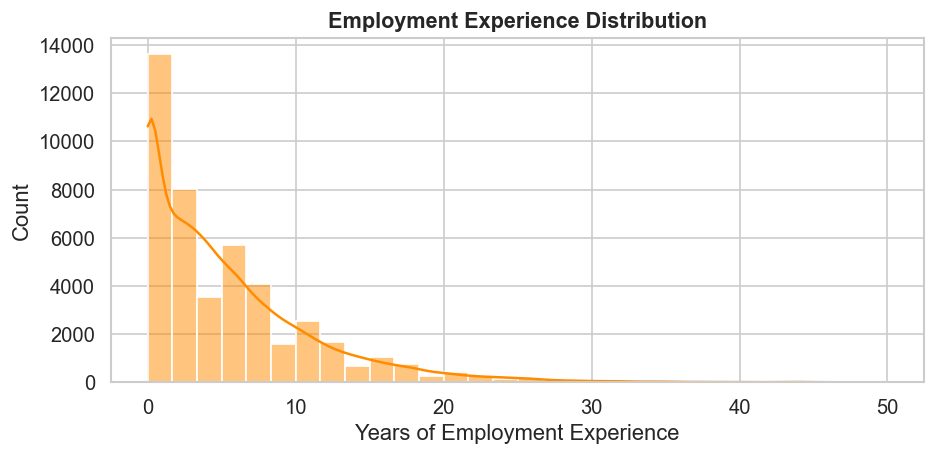

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['person_emp_exp'], bins=30, kde=True, ax=ax, color='darkorange')
ax.set_title("Employment Experience Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Years of Employment Experience")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Home Ownership

**Why it matters:** Home ownership is a strong indicator of financial stability and asset base. Homeowners — especially those with a mortgage — have demonstrated the ability to manage long-term debt obligations, which typically correlates with lower default rates.


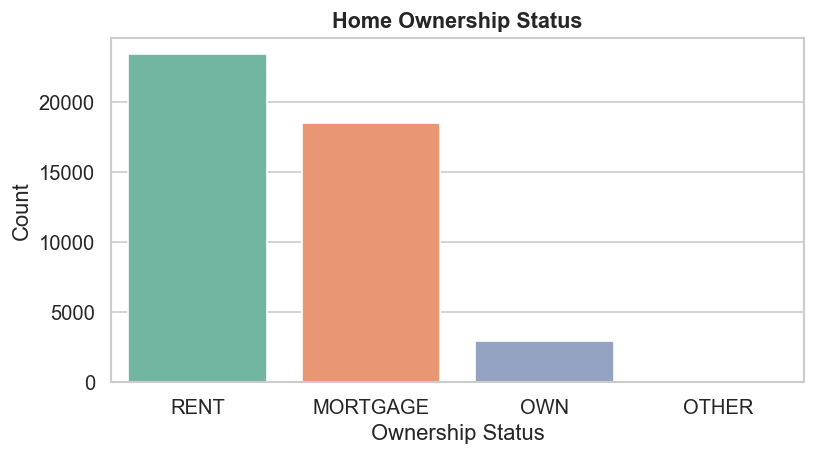

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df['person_home_ownership'].value_counts().index
sns.countplot(data=df, x='person_home_ownership', order=order, ax=ax, palette='Set2')
ax.set_title("Home Ownership Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Ownership Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Loan Amount

**Why it matters:** Large loan amounts relative to income increase default risk. A right-skewed distribution is typical — most loans are small, with a few large outliers.


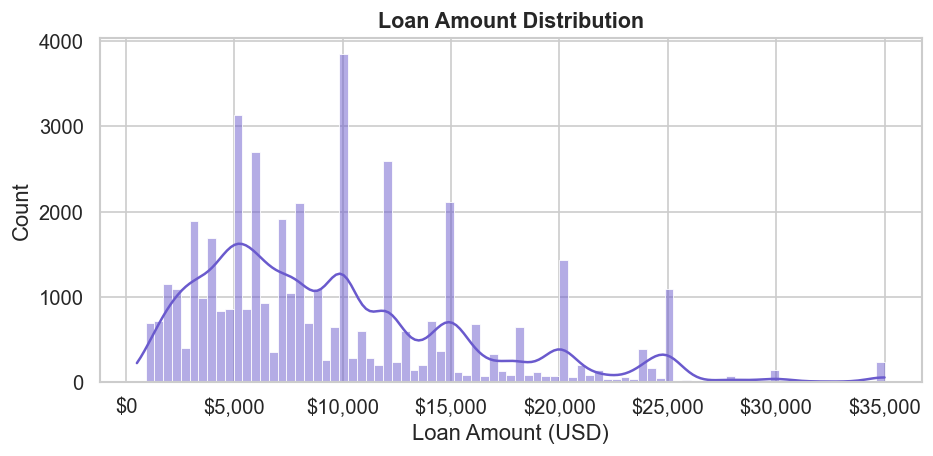

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['loan_amnt'], kde=True, ax=ax, color='slateblue')
ax.set_title("Loan Amount Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Amount (USD)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


### Loan Intent

**Why it matters:** The reason for borrowing is a powerful predictor. Debt consolidation loans, for instance, often indicate existing financial stress. Education loans may have lower default rates due to expected income growth. Medical and personal loans can have higher risk profiles.


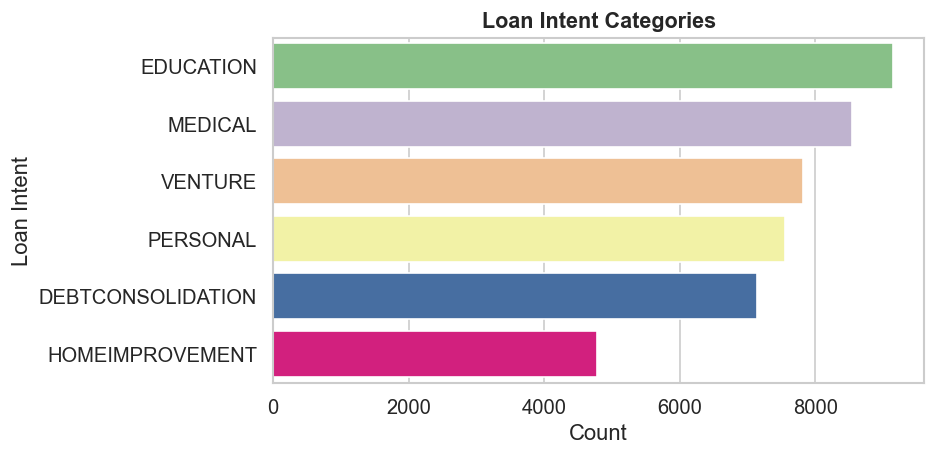

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
order = df['loan_intent'].value_counts().index
sns.countplot(data=df, y='loan_intent', order=order, ax=ax, palette='Accent')
ax.set_title("Loan Intent Categories", fontsize=13, fontweight='bold')
ax.set_xlabel("Count")
ax.set_ylabel("Loan Intent")
plt.tight_layout()
plt.show()


### Loan-to-Income Ratio (`loan_percent_income`)

**Why it matters:** This is essentially a proxy for the **Debt-to-Income (DTI)** ratio — one of the most important variables. Regulatory guidelines in many markets cap this at 40–43%. A high loan-to-income ratio dramatically increases default probability.


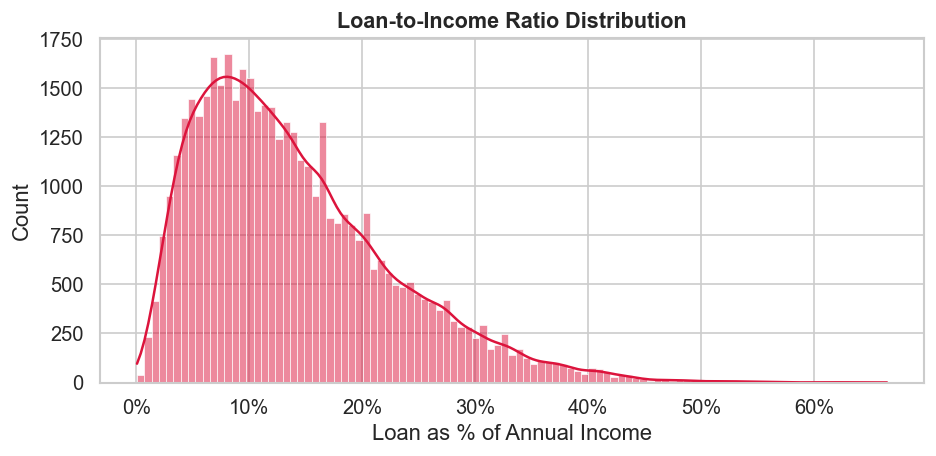

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['loan_percent_income'], kde=True, ax=ax, color='crimson')
ax.set_title("Loan-to-Income Ratio Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan as % of Annual Income")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


### Credit History Length

**Why it matters:** A longer credit history gives lenders more data to assess reliability. Applicants woth short history are inherently riskier because there is less evidence of consistent repayment behaviour.


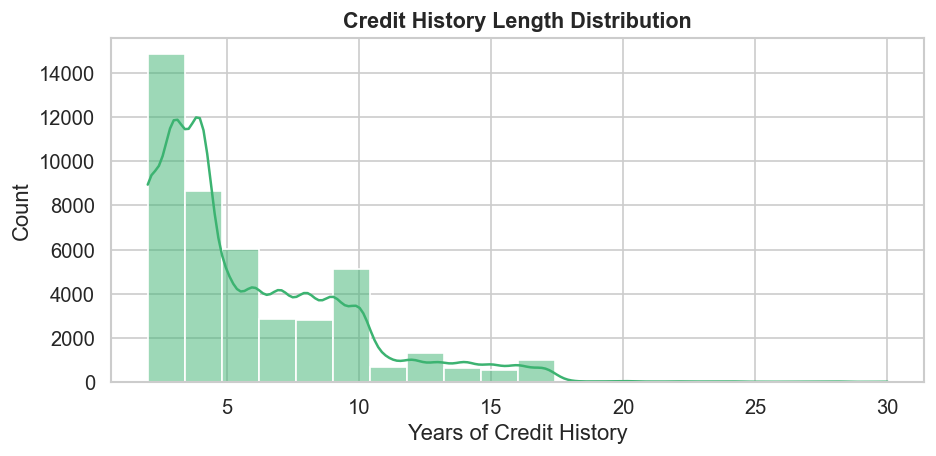

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['cb_person_cred_hist_length'], bins=20, kde=True, ax=ax, color='mediumseagreen')
ax.set_title("Credit History Length Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Years of Credit History")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Credit Score

**Why it matters:** The credit score is the most widely used single-number summary of creditworthiness. Scores typically follow a roughly normal distribution in a general population. In a loan applicant pool, we may see truncation at the lower end if the lender has a minimum score cutoff.

> **Benchmark ranges (FICO):** Poor < 580 | Fair 580–669 | Good 670–739 | Very Good 740–799 | Exceptional ≥ 800


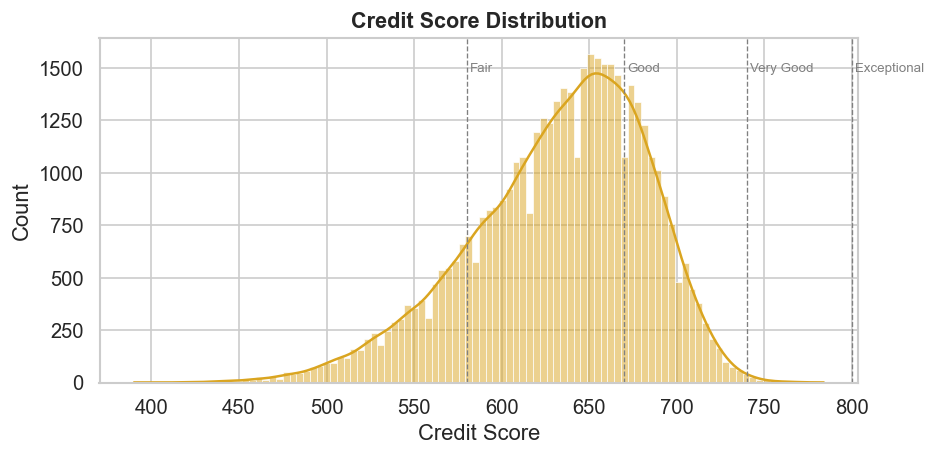

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['credit_score'], kde=True, ax=ax, color='goldenrod')
# Reference lines for score bands
for score, label in [(580, 'Fair'), (670, 'Good'), (740, 'Very Good'), (800, 'Exceptional')]:
    ax.axvline(score, linestyle='--', linewidth=0.8, color='grey')
    ax.text(score+2, ax.get_ylim()[1]*0.9, label, fontsize=8, color='grey')
ax.set_title("Credit Score Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Credit Score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### Previous Loan Defaults

**Why it matters:** This is one of the most predictive binary flags in credit risk. Past default behaviour is the single strongest predictor of future default in most credit scoring models. An applicant who has defaulted before is statistically far more likely to default again.


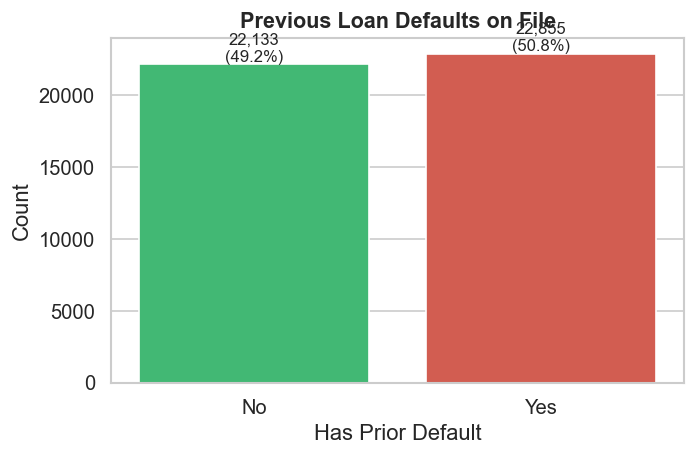

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['previous_loan_defaults_on_file'].value_counts()
sns.countplot(data=df, x='previous_loan_defaults_on_file', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Previous Loan Defaults on File", fontsize=13, fontweight='bold')
ax.set_xlabel("Has Prior Default")
ax.set_ylabel("Count")
for p in ax.patches:
    pct = p.get_height() / len(df) * 100
    ax.annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


## Bivariate Analysis — Target vs. Features

Now, we analyse how each feature relates to `loan_status` (our target: `0` = not defaulted, `1` = defaulted). This is where we uncover the most actionable insights for both credit policy and model feature selection.


### Income vs. Loan Status

A box plot lets us compare the income distribution between defaulted and non-defaulted groups. If our hypothesis holds, the median income for `loan_status = 1` should be lower.


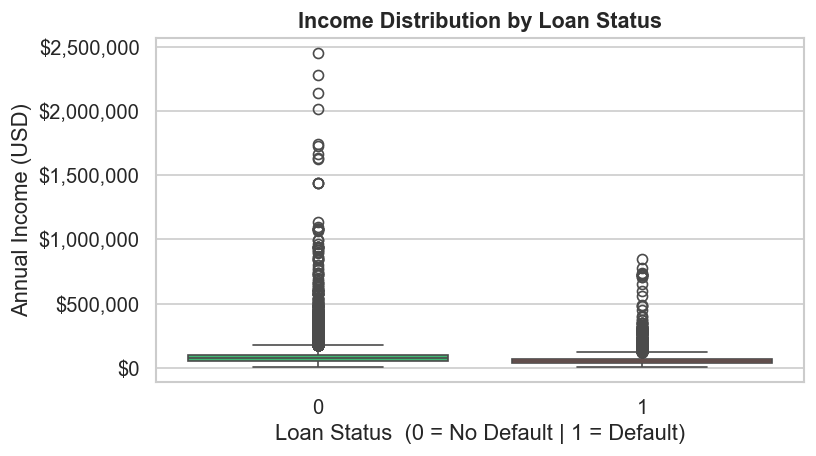

loan_status             0              1
count        3.498800e+04   10000.000000
mean         8.563188e+04   59886.096900
std          6.649352e+04   45338.315604
min          9.595000e+03    8000.000000
25%          5.147375e+04   36841.750000
50%          7.292600e+04   50629.000000
75%          1.019832e+05   71888.250000
max          2.448661e+06  845636.000000


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='loan_status', y='person_income', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Income Distribution by Loan Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Status  (0 = No Default | 1 = Default)")
ax.set_ylabel("Annual Income (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print(df.groupby('loan_status')['person_income'].describe().T)


### Age vs. Loan Status

Box plots here reveal whether defaulters skew younger, older, or show no age-based pattern.


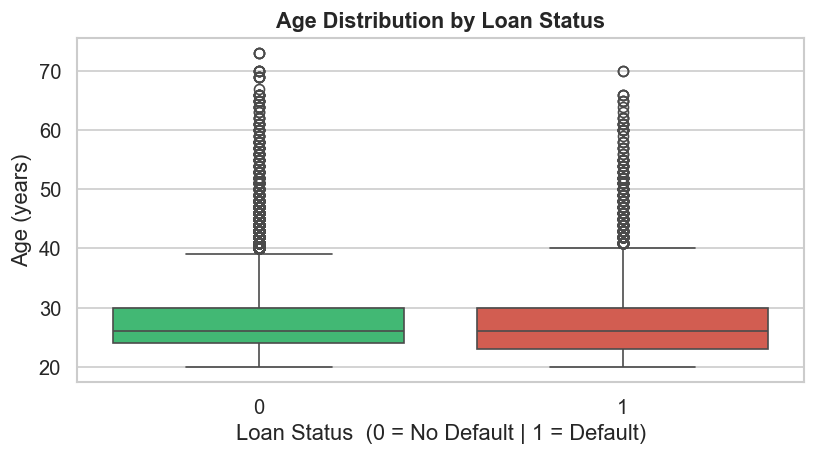

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='loan_status', y='person_age', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Age Distribution by Loan Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Status  (0 = No Default | 1 = Default)")
ax.set_ylabel("Age (years)")
plt.tight_layout()
plt.show()


### Credit History Length vs. Loan Status


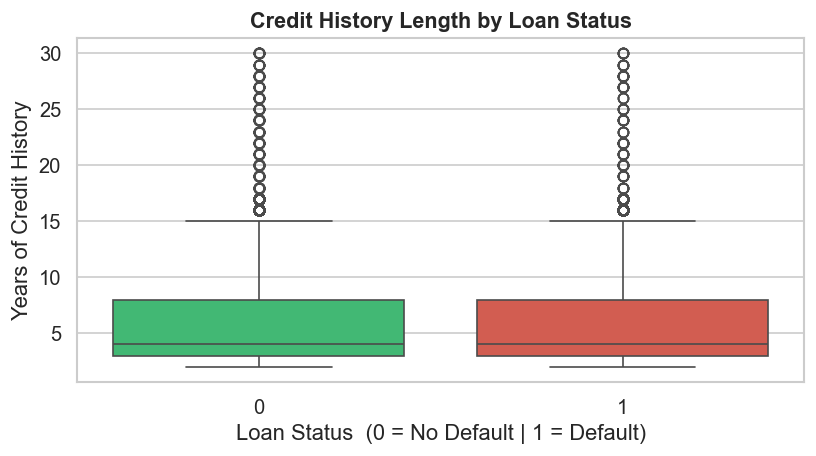

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Credit History Length by Loan Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Status  (0 = No Default | 1 = Default)")
ax.set_ylabel("Years of Credit History")
plt.tight_layout()
plt.show()


### Loan Amount vs. Loan Status


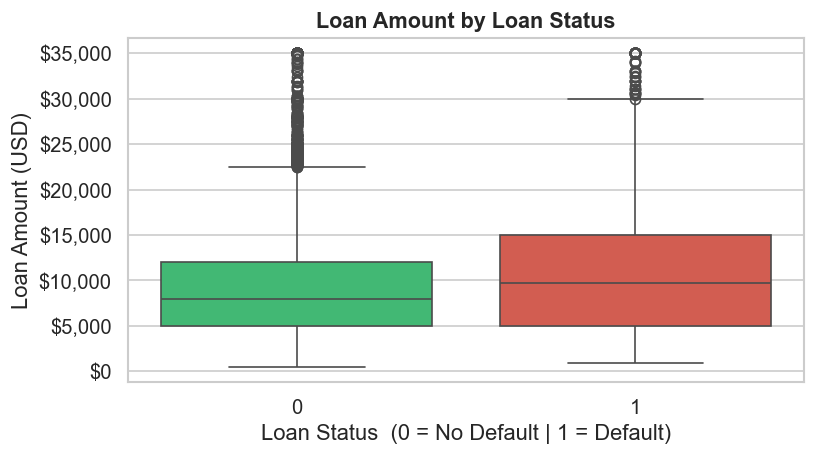

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='loan_status', y='loan_amnt', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Loan Amount by Loan Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Status  (0 = No Default | 1 = Default)")
ax.set_ylabel("Loan Amount (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


### Home Ownership vs. Default Rate

**Why a bar plot:** `loan_status` is binary (0/1), so the mean of `loan_status` grouped by home ownership gives us the **default rate per ownership category** — a direct, business-meaningful metric.



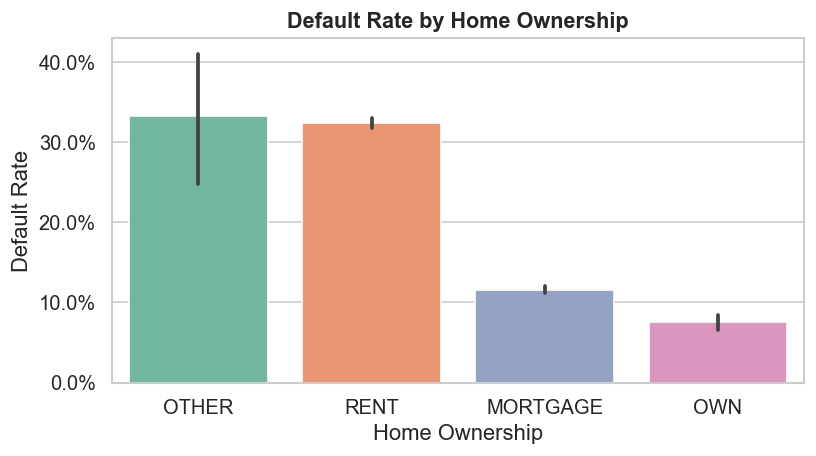

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False).index
sns.barplot(x='person_home_ownership', y='loan_status', data=df, order=order,
            ax=ax, palette='Set2', ci=95)
ax.set_title("Default Rate by Home Ownership", fontsize=13, fontweight='bold')
ax.set_xlabel("Home Ownership")
ax.set_ylabel("Default Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


### Employment Experience vs. Default Rate


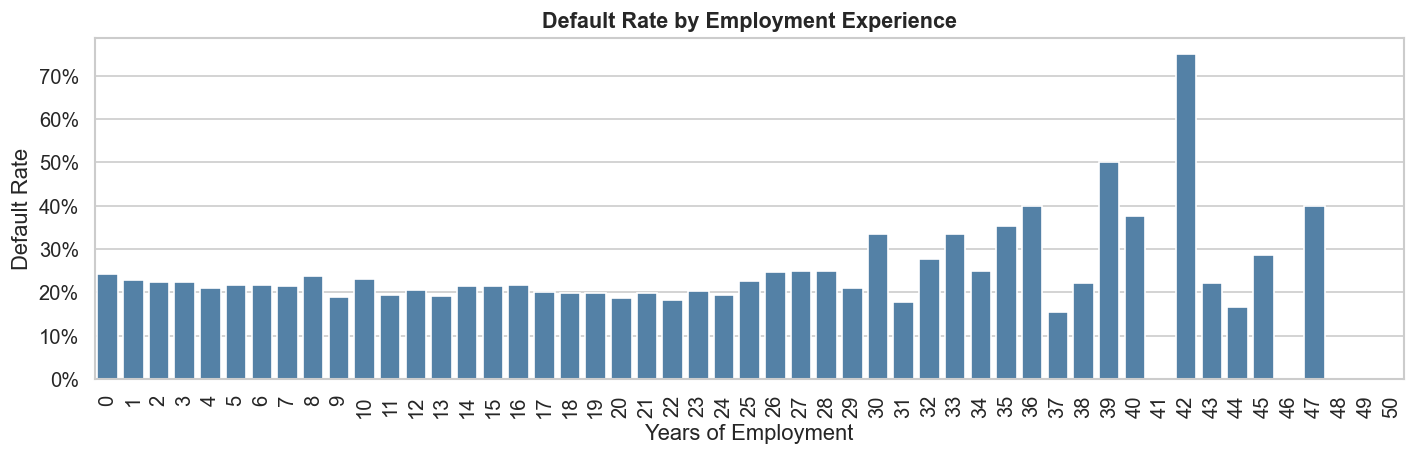

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
exp_default = df.groupby('person_emp_exp')['loan_status'].mean().reset_index()
sns.barplot(x='person_emp_exp', y='loan_status', data=exp_default, ax=ax, color='steelblue')
ax.set_title("Default Rate by Employment Experience", fontsize=13, fontweight='bold')
ax.set_xlabel("Years of Employment")
ax.set_ylabel("Default Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Loan Intent vs. Default Rate

**Why this matters:** This is one of the most practically useful charts for a credit analyst. Different loan purposes have fundamentally different risk profiles:
- **Debt consolidation** borrowers are already under financial stress
- **Education** borrowers expect future income growth
- **Medical** borrowers may have emergency financial pressure
- **Venture** borrowers face business risk

Lenders often apply different interest rates or approval thresholds by loan intent.


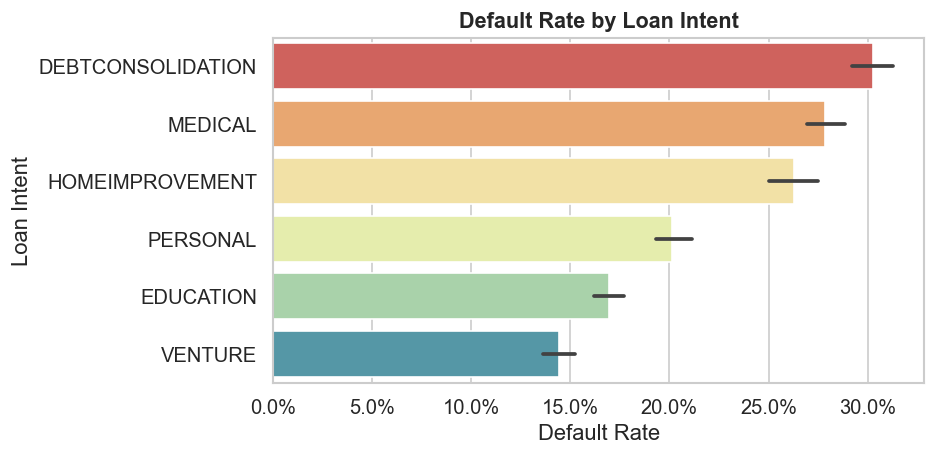

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
order = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False).index
sns.barplot(y='loan_intent', x='loan_status', data=df, order=order,
            ax=ax, palette='Spectral', ci=95)
ax.set_title("Default Rate by Loan Intent", fontsize=13, fontweight='bold')
ax.set_ylabel("Loan Intent")
ax.set_xlabel("Default Rate")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


### Credit Score vs. Loan Status

**Why it matters:** This is the most direct test of whether credit scores are predictive in this dataset. If the score is doing its job, defaulters should cluster in lower score bands.


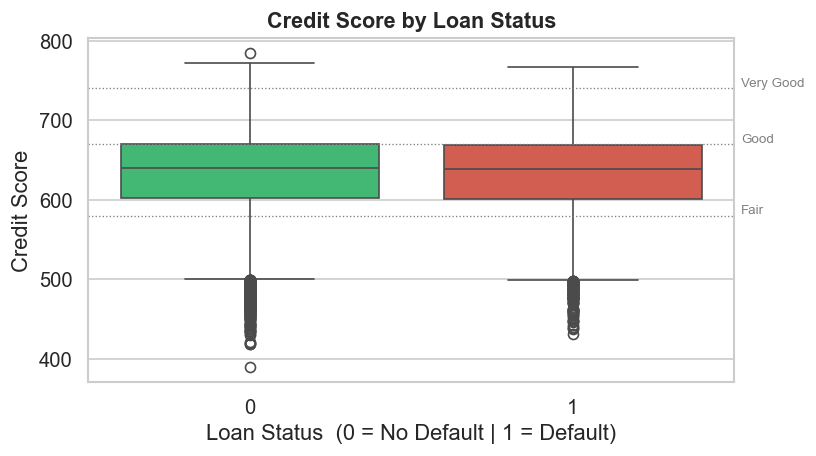

loan_status             0             1
count        34988.000000  10000.000000
mean           632.769407    631.887200
std             50.416284     50.293485
min            390.000000    431.000000
25%            602.000000    601.000000
50%            640.000000    639.000000
75%            670.000000    669.000000
max            784.000000    767.000000


In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='loan_status', y='credit_score', data=df, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title("Credit Score by Loan Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Loan Status  (0 = No Default | 1 = Default)")
ax.set_ylabel("Credit Score")
# FICO band references
for score, label in [(580, 'Fair'), (670, 'Good'), (740, 'Very Good')]:
    ax.axhline(score, linestyle=':', linewidth=0.8, color='grey')
    ax.text(1.52, score+2, label, fontsize=8, color='grey')
plt.tight_layout()
plt.show()
print(df.groupby('loan_status')['credit_score'].describe().T)


### Previous Defaults vs. Loan Status

**Why it matters:** Prior default history is typically the #1 predictor in credit scorecards. This cross-tab reveals the empirical default rate for applicants who have vs. have not defaulted before.


Default rate (%) by Prior Default History:
loan_status                     No Default (%)  Default (%)
previous_loan_defaults_on_file                             
No                                   54.818597    45.181403
Yes                                 100.000000     0.000000


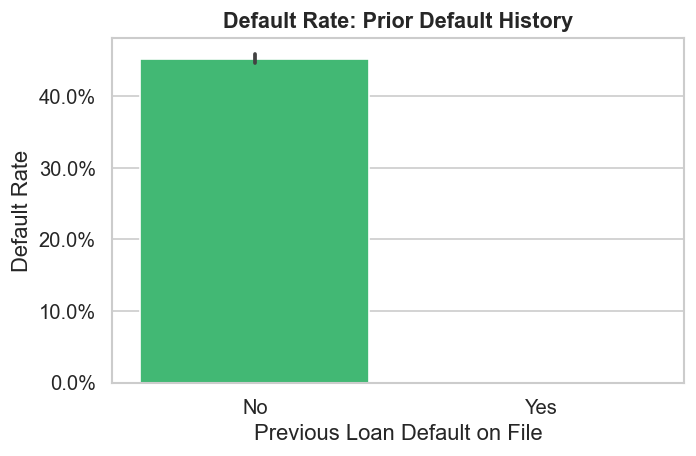

In [29]:
cross = pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index') * 100
print("Default rate (%) by Prior Default History:")
print(cross.rename(columns={0: 'No Default (%)', 1: 'Default (%)'}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x='previous_loan_defaults_on_file', y='loan_status', data=df, ax=ax,
            palette=['#2ecc71', '#e74c3c'], ci=95)
ax.set_title("Default Rate: Prior Default History", fontsize=13, fontweight='bold')
ax.set_xlabel("Previous Loan Default on File")
ax.set_ylabel("Default Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


## Key Insights & Business Implications

Below is a synthesis of the most important findings from this EDA, framed in terms of **credit risk business decisions**.

---

### 📌 Insight 1: Prior Default is the Strongest Risk Signal
Applicants with a prior default on file show dramatically higher current default rates. **Implication:** This binary flag should be one of the top features in any credit scoring model, and lenders may want to apply stricter terms or outright rejections for this segment.

---

### 📌 Insight 2: Credit Score is Predictive but Not Definitive
Defaulters have measurably lower credit scores, but the distributions overlap — there is no clean cutoff. **Implication:** Credit score alone is insufficient; it must be combined with income, DTI, and other behavioural signals for accurate risk segmentation.

---

### 📌 Insight 3: Loan Intent Reveals Structural Risk Differences
Certain loan intents (e.g., debt consolidation, medical) show higher default rates. **Implication:** Risk-based pricing should vary by loan intent. Lenders can offer lower rates for education/personal loans and price in higher risk premiums for consolidation or medical loans.

---

### 📌 Insight 4: Loan-to-Income Ratio is a Critical Affordability Metric
The distribution of `loan_percent_income` shows many applicants borrowing a high fraction of their annual income. **Implication:** Implementing a hard DTI cap (e.g., reject if loan > 40% of annual income) is a straightforward policy lever to reduce portfolio risk.

---

### 📌 Insight 5: Home Ownership Signals Stability
Renters exhibit higher default rates than homeowners. **Implication:** Home ownership status should be included as a feature in the model and may justify differentiated product offerings.

---

### 📌 Insight 6: Income Distribution is Highly Skewed
The income distribution requires log transformation for meaningful analysis. **Implication:** Log-transform income before feeding it into linear models (Logistic Regression, Linear SVM) to improve convergence and coefficient interpretability.

---

### 🔮 Next Steps

1. **Feature Engineering:** Create DTI ratio, income × credit score interaction, age-experience ratio
2. **Correlation Analysis & Heatmap:** Detect multicollinearity before modelling
3. **Class Imbalance Check:** Verify `loan_status` ratio; apply SMOTE or class weighting if needed
4. **Baseline Model:** Logistic Regression with interpretable coefficients (suitable for regulatory explainability)
5. **Advanced Models:** Gradient Boosting (XGBoost/LightGBM) for predictive accuracy
6. **Model Evaluation:** Focus on **ROC-AUC** and **Gini coefficient** — standard metrics in credit risk
